## Segment syllables

In [1]:
%matplotlib inline

import pickle
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
from scipy import signal
from scipy.signal import filtfilt, spectrogram, hilbert, savgol_filter, decimate

np.set_printoptions(precision=3, suppress=True)

In [2]:
!pip install git+https://github.com/timsainb/vocalization-segmentation.git@8bc85ee9bb644cc5928535959faee5e5b184dd36
from vocalseg.continuity_filtering import continuity_segmentation, plot_labelled_elements
from vibe.vocalseg_defaults import get_default_params

  Cloning https://github.com/timsainb/vocalization-segmentation.git (to revision 8bc85ee9bb644cc5928535959faee5e5b184dd36) to /tmp/pip-req-build-rjrgmq4p
  Running command git clone --filter=blob:none --quiet https://github.com/timsainb/vocalization-segmentation.git /tmp/pip-req-build-rjrgmq4p
  Running command git rev-parse -q --verify 'sha^8bc85ee9bb644cc5928535959faee5e5b184dd36'
  Running command git fetch -q https://github.com/timsainb/vocalization-segmentation.git 8bc85ee9bb644cc5928535959faee5e5b184dd36
  Resolved https://github.com/timsainb/vocalization-segmentation.git to commit 8bc85ee9bb644cc5928535959faee5e5b184dd36
  Preparing metadata (setup.py) ... done


/mnt/cube/lo/envs/birdsong/lib/python3.8/site-packages/vocalseg/continuity_filtering.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
bout_df = pd.read_pickle('bird_A_songs.pkl')

#### Generate and review clustered acoustics

In [4]:
get_default_params()

{'n_fft': 512,
 'hop_length_ms': 1,
 'win_length_ms': 5,
 'ref_level_db': 10,
 'pre': 0.97,
 'min_level_db': -120,
 'silence_threshold': 0.07,
 'spectral_range': [400, 6000],
 'mask_thresh_std': 1.0,
 'figsize': (30, 3),
 'min_silence_for_spec': 0.01,
 'neighborhood_thresh': 0.25,
 'neighborhood_time_ms': 5,
 'neighborhood_freq_hz': 2000,
 'temporal_neighbor_merge_distance_ms': 5,
 'overlapping_element_merge_thresh': 0.25,
 'min_element_size_ms_hz': [10, 1000]}

In [34]:
seg_params = get_default_params()
seg_params['spectral_range'] = [300, 4000]
seg_params['mask_thresh_std'] = 0.5
seg_params['temporal_neighbor_merge_distance_ms'] = 15
seg_params['min_level_db'] = -80
seg_params['neighborhood_time_ms'] = 10
seg_params['min_element_size_ms_hz'] = [20, 3000]

def segment_bout(x: np.array, fs: int, verbose=True) -> dict:
    results = continuity_segmentation(
        x, # audio waveform
        fs, # sampling rate
        **seg_params, # segmentation parameters
        verbose=verbose # display output
    )
    return results

### Run the following three blocks for a few example bouts
Tune segmentation parameters

longest silence 0.8460000000000001
longest vocalization 0.3019999999999998


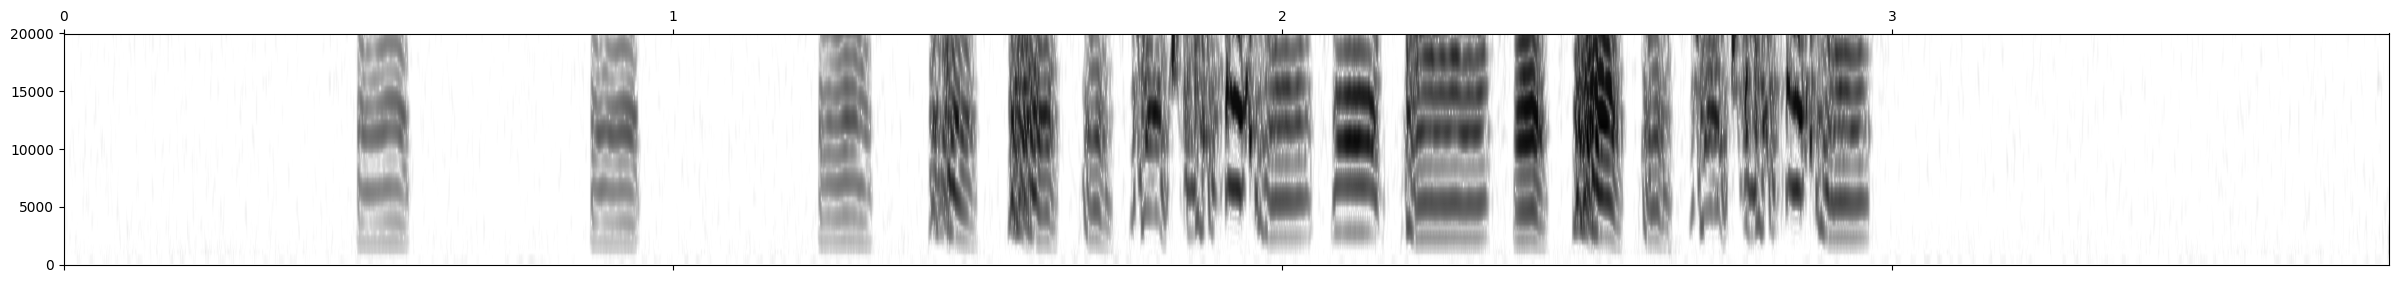

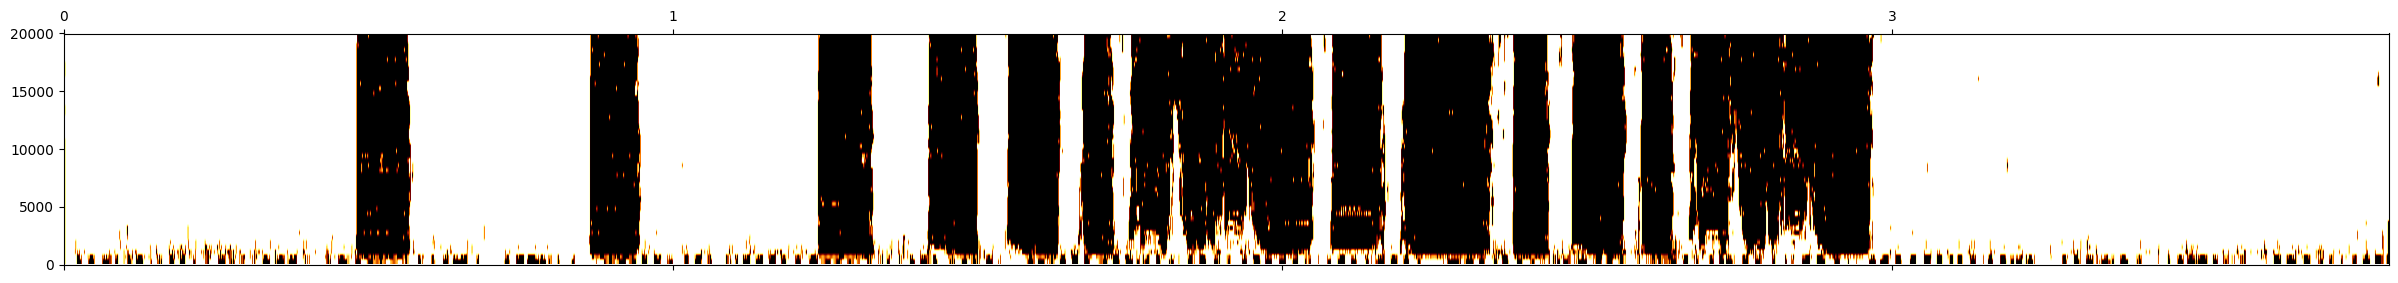

(25, 10)


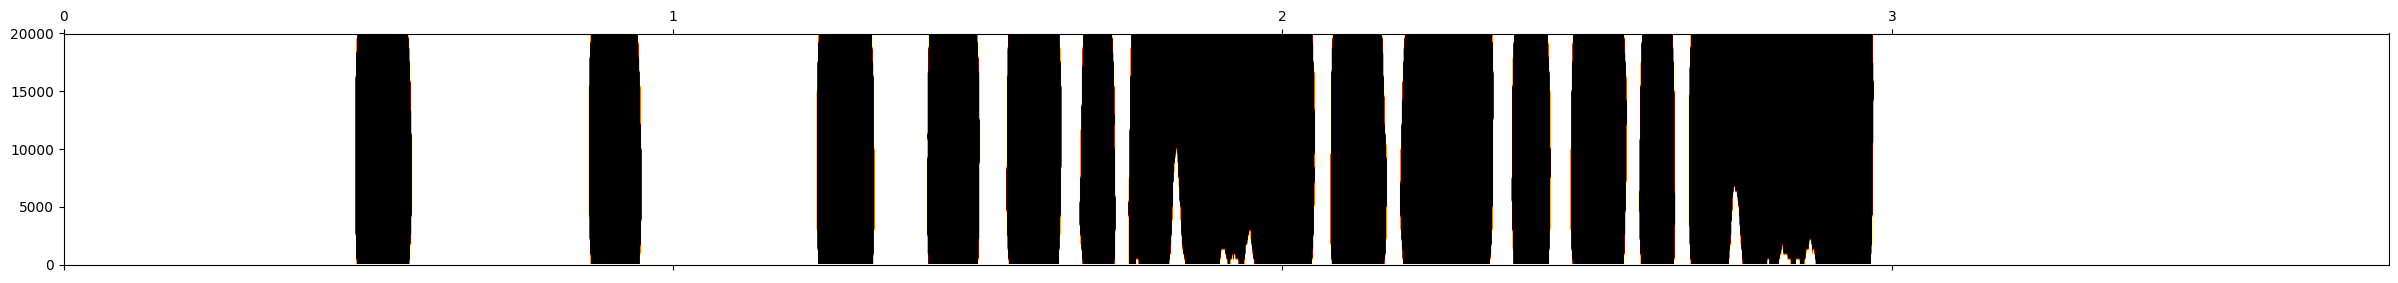

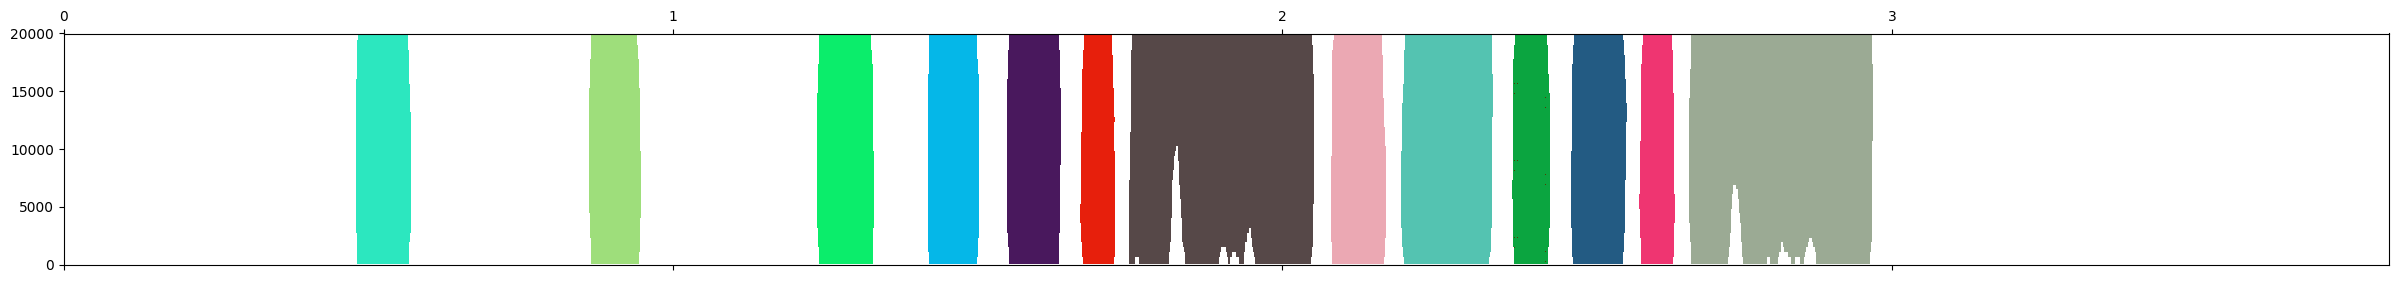

element coverage:   0%|          | 0/13 [00:00<?, ?it/s]

element length:   0%|          | 0/13 [00:00<?, ?it/s]

unique elements: 13


merging temporal neighbors:   0%|          | 0/13 [00:00<?, ?it/s]

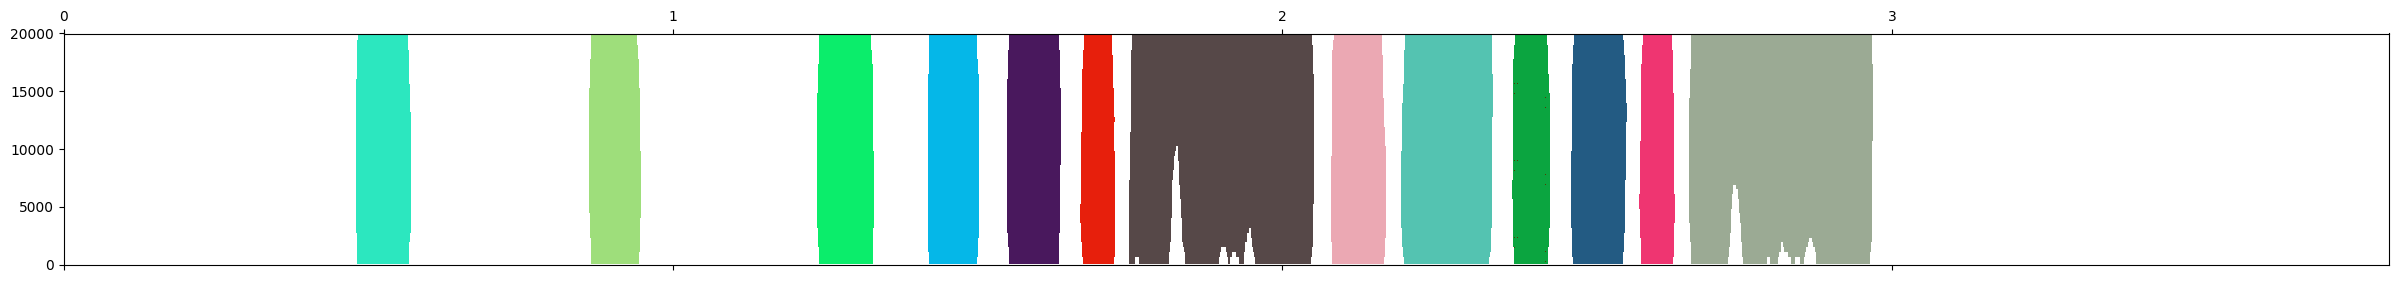

unique elements: 13
778


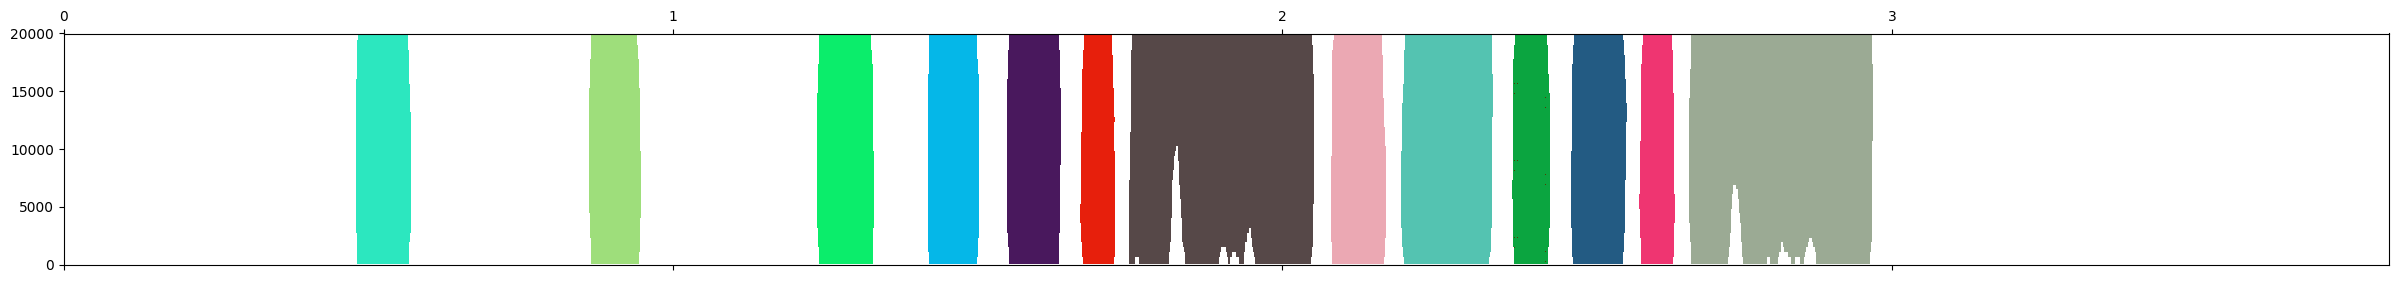

unique elements: 13


In [38]:
bout_idx = 3
x = bout_df.iloc[bout_idx]['waveform'].flatten()
x = x.astype(float)/np.max(np.abs(x))
results = segment_bout(x, bout_df.iloc[bout_idx]['sample_rate'])

  0%|          | 0/13 [00:00<?, ?it/s]

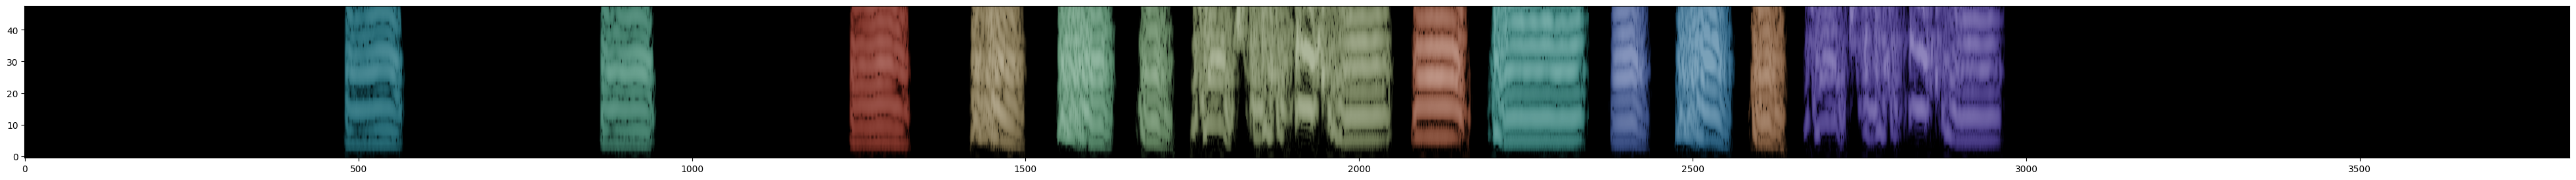

In [39]:
labelled_spec = plot_labelled_elements(results['elements'], results['spec'], background='black', figsize=(50,3)); 

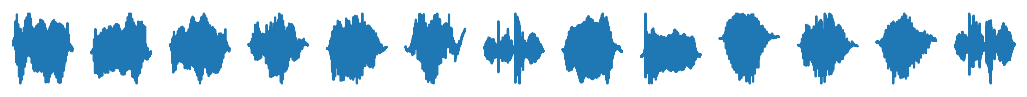

In [40]:
fig, axs = plt.subplots(ncols=len(results['onsets']), figsize= (len(results['onsets']),1))
for axi, (onset, offset) in enumerate(zip(results['onsets'], results['offsets'])):
    axs[axi].plot(x[int(onset*bout_df.iloc[0]['sample_rate']):int(offset*bout_df.iloc[0]['sample_rate'])])
    axs[axi].axis('off')

## When satisfied with parameters, run for full session

In [41]:
import os, sys, contextlib

@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, 'w') as devnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_out, old_err

In [42]:
# create bouts_segmented dataframe
bouts_segmented = bout_df.copy()
bouts_segmented['on_ms'] = None
bouts_segmented['off_ms'] = None
bouts_segmented['on_sample'] = None
bouts_segmented['off_sample'] = None

empty_waveforms = []
for bout_idx in bouts_segmented.index.to_list():
    
    # segment bouts
    x = bout_df.loc[bout_idx]['waveform'].flatten()
    if x.size==0:
        print(f"- bout_idx {bout_idx}: empty waveform, skipping...")
        empty_waveforms.append(bout_idx)
        continue
    x = x.astype(float)/np.max(np.abs(x))
    with suppress_output():
        results = segment_bout(x, bout_df.iloc[bout_idx]['sample_rate'], verbose=False)
    
    # update bouts_segmented
    bouts_segmented.at[bout_idx, 'on_ms'] = (np.array(results['onsets']) * 1000).astype(int)
    bouts_segmented.at[bout_idx, 'off_ms'] = (np.array(results['offsets']) * 1000).astype(int)
    bouts_segmented.at[bout_idx, 'on_sample'] = (np.array(results['onsets']) * bout_df.at[bout_idx, 'sample_rate']).astype(int)
    bouts_segmented.at[bout_idx, 'off_sample'] = (np.array(results['offsets']) * bout_df.at[bout_idx, 'sample_rate']).astype(int)
    
bouts_segmented = bouts_segmented.drop(index=empty_waveforms)

element coverage:   0%|          | 0/65 [00:00<?, ?it/s]

element length:   0%|          | 0/65 [00:00<?, ?it/s]

merging temporal neighbors:   0%|          | 0/65 [00:00<?, ?it/s]

element coverage:   0%|          | 0/20 [00:00<?, ?it/s]

element length:   0%|          | 0/20 [00:00<?, ?it/s]

...

element length:   0%|          | 0/10 [00:00<?, ?it/s]

merging temporal neighbors:   0%|          | 0/10 [00:00<?, ?it/s]

element coverage:   0%|          | 0/11 [00:00<?, ?it/s]

element length:   0%|          | 0/11 [00:00<?, ?it/s]

merging temporal neighbors:   0%|          | 0/11 [00:00<?, ?it/s]

#### Make separated syllables

In [43]:
# create a dataframe for segmented syllables
dfs = []
for index, row in bouts_segmented.iterrows():
    sample_rate = row['sample_rate']
    bout_index = index
    bout_waveform = row['waveform']
    on_samples = row['on_sample']
    off_samples = row['off_sample']
    on_mss = row['on_ms']
    off_mss = row['off_ms']
    data = []
    for syllable_index, (on_sample, 
                         off_sample, 
                         on_ms, 
                         off_ms) in enumerate(zip(on_samples, 
                                                  off_samples, 
                                                  on_mss, 
                                                  off_mss)
                                              ):
        
        data.append({
            'sample_rate': sample_rate,
            'bout_index': bout_index,
            'bout_waveform': bout_waveform,
            'syllable_index': syllable_index,
            'on_sample': on_sample,
            'off_sample': off_sample,
            'on_ms': on_ms,
            'off_ms': off_ms,
            'syllable_waveform': bout_waveform[on_sample:off_sample]})
    
    df = pd.DataFrame(data)
    dfs.append(df)

syl_df = pd.concat(dfs, ignore_index=True)

In [44]:
# remove empty syllables (product of errors in segmentation)
empty_rows = []
for i, arr in enumerate(syl_df.syllable_waveform.values):
    if len(arr) == 0: empty_rows.append(i)
if empty_rows:
    print('Bouts with empty syllables:', syl_df.iloc[empty_rows]['bout_index'].unique())

syl_df = syl_df[syl_df['syllable_waveform'].apply(lambda x: len(x) != 0)]

In [45]:
# remove segs under 10ms
syl_df = syl_df.sort_values(by=['bout_index', 'on_ms'])
syl_df = syl_df[(syl_df['off_ms'] - syl_df['on_ms']) >= 10]
syl_df['syllable_index'] = syl_df.groupby('bout_index').cumcount()
syl_df = syl_df.reset_index(drop=True)

#### BETA: screen out wingbeat noise
Can't guarantee this will generalize across birds

In [46]:
from scipy.signal import stft
from skimage.transform import resize

def make_spec(syll_wav, fs, n_fft=512, hop_length_ms=1, win_length_ms=4,
              fmin=300, fmax=10000, out_shape=(64, 64)):
    y = np.asarray(syll_wav, dtype=float)
    win_length = int(win_length_ms / 1000 * fs)
    hop_length = int(hop_length_ms / 1000 * fs)

    f, _, Z = stft(y, fs=fs, window='hann', nperseg=win_length,
                   noverlap=win_length - hop_length, nfft=n_fft, boundary=None)
    S = np.abs(Z)

    band = (f >= fmin) & (f <= fmax)
    S = S[band]

    S = np.log1p(S)
    S = resize(S, out_shape, anti_aliasing=True)
    return S

syllables_wav = syl_df.syllable_waveform.values
syllables_rate = syl_df.sample_rate.values

specs = np.array([make_spec(w, r) for w, r in zip(syllables_wav, syllables_rate)])

In [47]:
def _cpp_frame(log_power, fs, f0_min, f0_max):
    cep = np.fft.irfft(log_power)
    q = np.arange(len(cep))
    q_lo = int(np.floor(fs / f0_max))
    q_hi = min(int(np.ceil(fs / f0_min)), len(cep) - 1)
    if q_hi <= q_lo + 2:
        return 0.0
    band, qb = cep[q_lo:q_hi], q[q_lo:q_hi]
    A = np.vstack([qb, np.ones_like(qb)]).T
    coef, *_ = np.linalg.lstsq(A, band, rcond=None)
    return (band - A @ coef).max()

def syllable_features(seg, fs, nperseg=1024, noverlap=768,
                      fmin=400, fmax=20000, f0_min=400, f0_max=2500, cpp_pct=90):
    seg = np.asarray(seg, float)
    if len(seg) < nperseg:
        seg = np.pad(seg, (0, nperseg - len(seg)))
    f, _, Sxx = spectrogram(seg, fs=fs, nperseg=nperseg, noverlap=noverlap)
    psd = Sxx.mean(axis=1)
    band = (f >= fmin) & (f <= fmax)
    fb, pb = f[band], psd[band]
    p = pb / (pb.sum() + 1e-12)
    centroid = (fb * p).sum()
    flatness = np.exp(np.mean(np.log(pb + 1e-12))) / (np.mean(pb) + 1e-12)
    hi = pb[(fb >= 7500) & (fb < 10000)].sum()
    lo = pb[(fb >= 400) & (fb < 1000)].sum()
    hilo = hi / (lo + 1e-12)
    logP = np.log(Sxx + 1e-12)
    cpps = [_cpp_frame(logP[:, i], fs, f0_min, f0_max) for i in range(logP.shape[1])]
    cpp = np.percentile(cpps, cpp_pct)
    return centroid, flatness, hilo, cpp

feats = np.array([
    syllable_features(syl['syllable_waveform'], syl['sample_rate'])
    for _, syl in syl_df.iterrows()
])

feats_oriented = feats * np.array([1, 1, 1, -1])   # centroid, flatness, hilo, cpp
z = (feats_oriented - feats_oriented.mean(axis=0)) / (feats_oriented.std(axis=0))
noise_score = z.sum(axis=1)

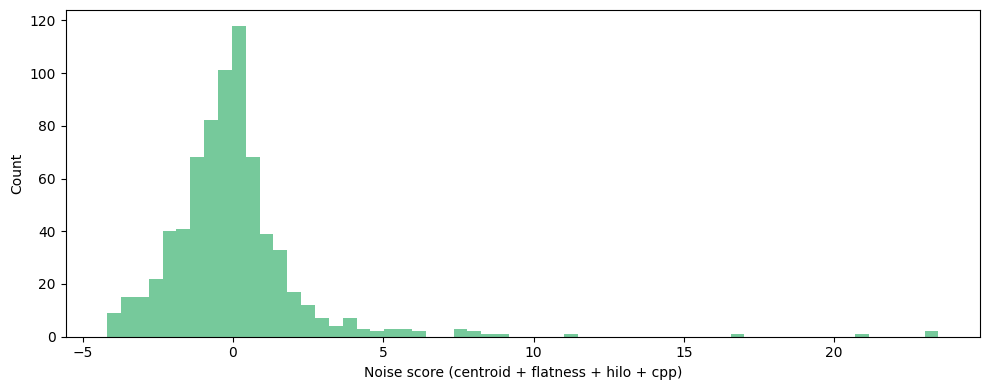

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(noise_score, bins=60, color='mediumseagreen', alpha=0.7)
ax.set_xlabel('Noise score (centroid + flatness + hilo + cpp)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

5 noise syllables found


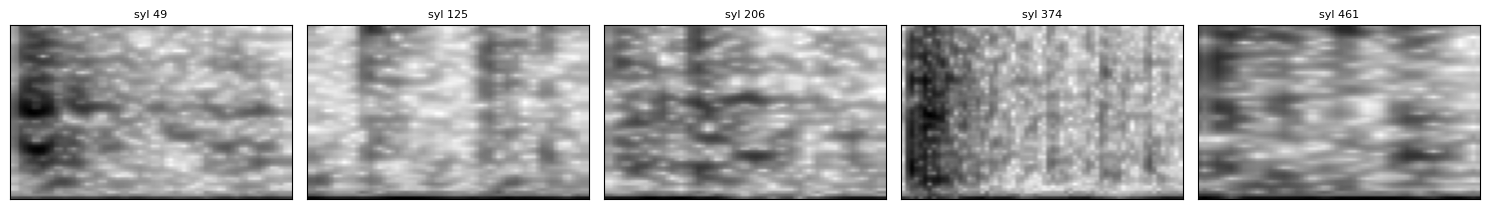

In [49]:
noise = np.where(noise_score > 10)[0]
print(f"{len(noise)} noise syllables found")

n = len(noise); ncol = 5; nrow = max(1, int(np.ceil(n / ncol)))
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 2.2*nrow), squeeze=False)
for ax, i in zip(axes.flat, noise):
    ax.imshow(specs[i], origin='lower', aspect='auto', cmap='gray_r')
    ax.set_title(f'syl {syl_df.index[i]}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

In [50]:
syl_df = syl_df.drop(index=syl_df.index[noise]).reset_index(drop=True)
print(f"dropped {len(noise)}, {len(syl_df)} syllables remain")

dropped 5, 718 syllables remain


In [51]:
syl_df['syllable_index'] = syl_df.groupby('bout_index').cumcount()
syl_df = syl_df.reset_index(drop=True)

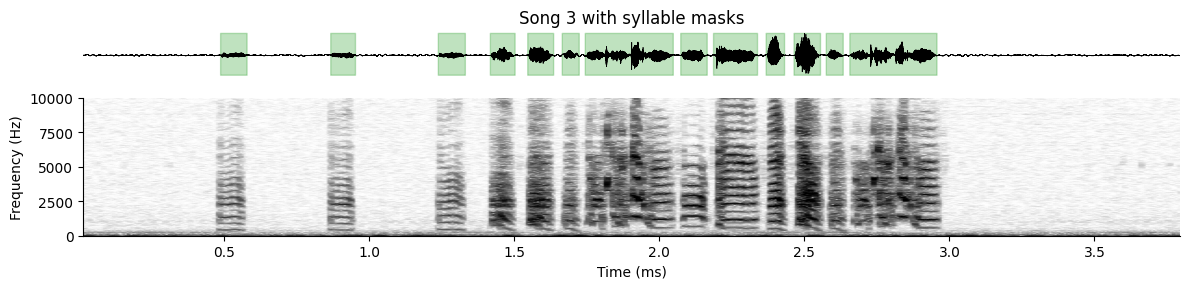

In [52]:
fig, ax = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [1,3]}, figsize=(12, 3))
bout_idx = 3
x = bout_df.iloc[bout_idx].waveform
x = x/max(np.min(x), np.max(x), key=abs)
fs = bout_df.iloc[bout_idx].sample_rate
t_wave = np.arange(len(x)) / fs
freq, t_spec, Sxx = spectrogram(x, fs=fs, nperseg=1024, noverlap=768)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

win_length=int(0.016*fs)
hop_length=int(0.004*fs)
n_fft=2 ** math.ceil(math.log2(win_length))
def get_stft_frame_count(y, fs, win_length, hop_length, n_fft):
    _, t, _ = signal.stft(y, fs=fs, window='hann', nperseg=win_length,
                          noverlap=win_length-hop_length, nfft=n_fft,
                          return_onesided=True, boundary='zeros', padded=True)
    return len(t)

# sound waveform
ax[0].plot(t_wave, x, 'black', lw=0.5)
T = get_stft_frame_count(x, fs, win_length, hop_length, n_fft)
m = np.zeros(len(x), dtype=bool)
syl_rows = syl_df[syl_df['bout_index'] == bout_idx]
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(x))
    m[start_n:end_n] = True
ax[0].fill_between(t_wave, -1, 1, where=m, alpha=0.3, color='C2')
ax[0].set_xlim([t_wave[0], t_wave[-1]])
ax[0].set_axis_off()
ax[0].set_ylabel('Amplitude')
ax[0].set_title(f'Song {bout_idx} with syllable masks')

# spectrogram
fmask = freq <= 10000
ax[1].pcolormesh(t_spec, freq[fmask], Sxx_db[fmask], cmap='Greys', shading='gouraud',
                      vmin=np.percentile(Sxx_db, 20), vmax=np.percentile(Sxx_db, 99.9))
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_xlabel('Time (ms)')
ax[1].set_xlim([t_spec[0], t_spec[-1]])
ax[1].set_ylim([0, 10000])
ax[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

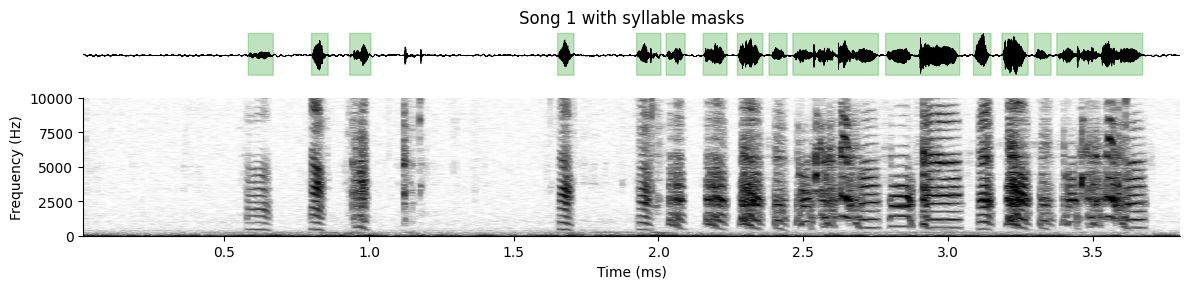

In [53]:
fig, ax = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [1,3]}, figsize=(12, 3))
bout_idx = 1
x = bout_df.iloc[bout_idx].waveform
x = x/max(np.min(x), np.max(x), key=abs)
fs = bout_df.iloc[bout_idx].sample_rate
t_wave = np.arange(len(x)) / fs
freq, t_spec, Sxx = spectrogram(x, fs=fs, nperseg=1024, noverlap=768)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

win_length=int(0.016*fs)
hop_length=int(0.004*fs)
n_fft=2 ** math.ceil(math.log2(win_length))
def get_stft_frame_count(y, fs, win_length, hop_length, n_fft):
    _, t, _ = signal.stft(y, fs=fs, window='hann', nperseg=win_length,
                          noverlap=win_length-hop_length, nfft=n_fft,
                          return_onesided=True, boundary='zeros', padded=True)
    return len(t)

# sound waveform
ax[0].plot(t_wave, x, 'black', lw=0.5)
T = get_stft_frame_count(x, fs, win_length, hop_length, n_fft)
m = np.zeros(len(x), dtype=bool)
syl_rows = syl_df[syl_df['bout_index'] == bout_idx]
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(x))
    m[start_n:end_n] = True
ax[0].fill_between(t_wave, -1, 1, where=m, alpha=0.3, color='C2')
ax[0].set_xlim([t_wave[0], t_wave[-1]])
ax[0].set_axis_off()
ax[0].set_ylabel('Amplitude')
ax[0].set_title(f'Song {bout_idx} with syllable masks')

# spectrogram
fmask = freq <= 10000
ax[1].pcolormesh(t_spec, freq[fmask], Sxx_db[fmask], cmap='Greys', shading='gouraud',
                      vmin=np.percentile(Sxx_db, 20), vmax=np.percentile(Sxx_db, 99.9))
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_xlabel('Time (ms)')
ax[1].set_xlim([t_spec[0], t_spec[-1]])
ax[1].set_ylim([0, 10000])
ax[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

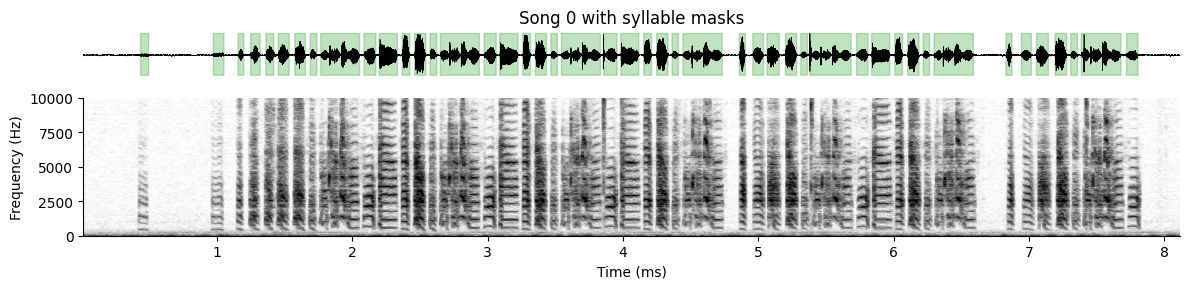

In [54]:
fig, ax = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [1,3]}, figsize=(12, 3))
bout_idx = 0
x = bout_df.iloc[bout_idx].waveform
x = x/max(np.min(x), np.max(x), key=abs)
fs = bout_df.iloc[bout_idx].sample_rate
t_wave = np.arange(len(x)) / fs
freq, t_spec, Sxx = spectrogram(x, fs=fs, nperseg=1024, noverlap=768)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

win_length=int(0.016*fs)
hop_length=int(0.004*fs)
n_fft=2 ** math.ceil(math.log2(win_length))
def get_stft_frame_count(y, fs, win_length, hop_length, n_fft):
    _, t, _ = signal.stft(y, fs=fs, window='hann', nperseg=win_length,
                          noverlap=win_length-hop_length, nfft=n_fft,
                          return_onesided=True, boundary='zeros', padded=True)
    return len(t)

# sound waveform
ax[0].plot(t_wave, x, 'black', lw=0.5)
T = get_stft_frame_count(x, fs, win_length, hop_length, n_fft)
m = np.zeros(len(x), dtype=bool)
syl_rows = syl_df[syl_df['bout_index'] == bout_idx]
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(x))
    m[start_n:end_n] = True
ax[0].fill_between(t_wave, -1, 1, where=m, alpha=0.3, color='C2')
ax[0].set_xlim([t_wave[0], t_wave[-1]])
ax[0].set_axis_off()
ax[0].set_ylabel('Amplitude')
ax[0].set_title(f'Song {bout_idx} with syllable masks')

# spectrogram
fmask = freq <= 10000
ax[1].pcolormesh(t_spec, freq[fmask], Sxx_db[fmask], cmap='Greys', shading='gouraud',
                      vmin=np.percentile(Sxx_db, 20), vmax=np.percentile(Sxx_db, 99.9))
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_xlabel('Time (ms)')
ax[1].set_xlim([t_spec[0], t_spec[-1]])
ax[1].set_ylim([0, 10000])
ax[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [55]:
syl_df.to_pickle('bird_A_syls.pkl')